# Live observation of an event stream: one producer, three consumers

This notebook runs the workflow Frames2Py is built for. An event stream arrives at its own
pace and is accumulated by an `Engine`. Several pieces of downstream work read the published
state independently: a tracker, a deliberately slow stand-in for a model, and a monitor.
The question it answers is practical: what does each consumer see, what does a slow consumer
cost, and who pays for it?

Three kinds of content are kept apart, and each section says which it is:

- **Demonstration data.** Every event here comes from a small deterministic generator
  defined in section 1. It is not a recording and does not model any real sensor's noise,
  bandwidth or optics. Nothing measured on it says anything about a real camera or a real
  model.
- **Frames2Py behaviour.** What the library does with the events: validation, accumulation,
  publication, snapshots, sequence and watermark metadata, `reset()`. This holds for any
  input that meets the event contract.
- **Downstream analysis.** The modest work the consumers do with the snapshots: a centroid
  tracker and a velocity estimate, checked against the generator's known trajectory.

Run it from a repository checkout with the `notebook` dependency group
(`uv sync --group notebook`, see `CONTRIBUTING.md`). It takes a few seconds; the live part
replays 3 s of events in real time. Threads and timing make some numbers differ from run to
run; the saved outputs are from one run.

In [1]:
import platform
import threading
import time

import matplotlib.pyplot as plt
import numpy as np

import frames2py
from frames2py import replay

plt.rcParams.update({"figure.dpi": 72, "font.size": 9})
INK, BLUE, AMBER = "#1D2433", "#3160F0", "#F2A900"  # the colours of the Frames2Py logo
print("frames2py", frames2py.__version__, "| NumPy", np.__version__, "| Python", platform.python_version())

frames2py 1.1.0 | NumPy 2.4.6 | Python 3.11.14


## 1. The demonstration data

*Demonstration data.* An event camera reports, per pixel, when the logarithm of the light it
sees changes by more than a threshold: an ON event when it gets brighter, an OFF event when
it gets darker. A bright object moving over a dark background therefore fires ON events
along its leading edge and OFF events along its trailing edge, and nothing where the scene
doesn't change.

The generator below produces a stream with that structure, and nothing more:

- a 346 x 260 sensor (the size of a DAVIS346, chosen only for its size);
- a bright disc of radius 18 px moving on a circle of radius 70 px around the sensor's
  centre, one revolution per second;
- every 0.5 ms it compares which pixels are inside the disc now and 0.5 ms earlier; each
  pixel the disc entered emits 3 ON events, each pixel it left emits 3 OFF events, at times
  drawn uniformly within that 0.5 ms;
- background activity: every pixel fires events of random polarity as a Poisson process at
  1 Hz;
- three hot pixels, each firing at 2 kHz with random polarity.

Because the trajectory is a formula, the generator also gives the ground truth the analysis
in section 6 is checked against. The stream has two segments: 2 s, then a "camera restart"
whose clock begins again at 0 and whose disc starts a quarter turn further on (section 5).

In [2]:
W, H = 346, 260
CENTRE = np.array([173.0, 130.0])
ORBIT_PX, RADIUS_PX = 70.0, 18.0
PERIOD_US = 1_000_000          # one revolution per second
STEP_US = 500
EVENTS_PER_CROSSING = 3
NOISE_HZ = 1.0
HOT_PIXELS = [(31, 47), (290, 212), (120, 20)]  # (x, y)
HOT_HZ = 2_000.0


def disc_centre(t_us, phase):
    a = 2 * np.pi * np.asarray(t_us, dtype=np.float64) / PERIOD_US + phase
    return CENTRE[0] + ORBIT_PX * np.cos(a), CENTRE[1] + ORBIT_PX * np.sin(a)


def disc_velocity(t_us, phase):
    # Pixels per second.
    a = 2 * np.pi * np.asarray(t_us, dtype=np.float64) / PERIOD_US + phase
    omega = 2 * np.pi * 1e6 / PERIOD_US
    return -ORBIT_PX * omega * np.sin(a), ORBIT_PX * omega * np.cos(a)


def generate(duration_us, phase, seed):
    rng = np.random.default_rng(seed)
    ts, xs, ys, ps = [], [], [], []
    px, py = disc_centre(0, phase)
    for t in range(STEP_US, duration_us + 1, STEP_US):
        cx, cy = disc_centre(t, phase)
        x0, x1 = int(min(cx, px) - RADIUS_PX - 1), int(max(cx, px) + RADIUS_PX + 2)
        y0, y1 = int(min(cy, py) - RADIUS_PX - 1), int(max(cy, py) + RADIUS_PX + 2)
        gy, gx = np.mgrid[y0:y1, x0:x1]
        inside_now = (gx - cx) ** 2 + (gy - cy) ** 2 <= RADIUS_PX**2
        inside_before = (gx - px) ** 2 + (gy - py) ** 2 <= RADIUS_PX**2
        for changed, polarity in ((inside_now & ~inside_before, 1), (inside_before & ~inside_now, 0)):
            n = int(changed.sum()) * EVENTS_PER_CROSSING
            xs.append(np.repeat(gx[changed], EVENTS_PER_CROSSING))
            ys.append(np.repeat(gy[changed], EVENTS_PER_CROSSING))
            ts.append(rng.integers(t - STEP_US, t, n))
            ps.append(np.full(n, polarity))
        px, py = cx, cy
    n = rng.poisson(NOISE_HZ * W * H * duration_us / 1e6)
    ts.append(rng.integers(0, duration_us, n))
    xs.append(rng.integers(0, W, n))
    ys.append(rng.integers(0, H, n))
    ps.append(rng.integers(0, 2, n))
    for hx, hy in HOT_PIXELS:
        n = rng.poisson(HOT_HZ * duration_us / 1e6)
        ts.append(rng.integers(0, duration_us, n))
        xs.append(np.full(n, hx))
        ys.append(np.full(n, hy))
        ps.append(rng.integers(0, 2, n))
    t = np.concatenate(ts)
    order = np.argsort(t, kind="stable")
    events = np.empty(len(t), dtype=frames2py.EVENT_DTYPE)
    events["t"] = t[order]
    events["x"] = np.concatenate(xs)[order]
    events["y"] = np.concatenate(ys)[order]
    events["p"] = np.concatenate(ps)[order]
    return events


SEGMENTS = [  # (duration in µs, the disc's starting phase, random seed)
    (2_000_000, 0.0, 1),
    (1_000_000, np.pi / 2, 2),
]
streams = [generate(duration, phase, seed) for duration, phase, seed in SEGMENTS]
for i, s in enumerate(streams, 1):
    print(f"segment {i}: {len(s):,} events, t = {s['t'][0]} to {s['t'][-1]} µs")

segment 1: 381,727 events, t = 1 to 1999997 µs
segment 2: 190,985 events, t = 14 to 999999 µs


## 2. The event contract

*Frames2Py behaviour.* Frames2Py takes events at one boundary: a 1-D, C-contiguous NumPy
structured array with fields `t` (uint64 µs), `x` and `y` (uint16; `x` is the column, `y`
the row, `(0, 0)` top-left) and `p` (uint8; 0 is OFF, anything else ON). `EVENT_DTYPE` is
that layout, 13 bytes per event. Whatever produces your events, a camera SDK, a file
adapter or a generator like the one above, converts to this once, at the edge.

The checks are structural and cheap: the wrong field dtype is a `TypeError`, and a call
holding any timestamp at or above 2^63 is rejected whole with `ValueError`, before anything
changes. Values are not otherwise inspected; events outside the sensor are counted, not
accumulated.

In [3]:
print(frames2py.EVENT_DTYPE, "itemsize", frames2py.EVENT_DTYPE.itemsize)

check = frames2py.Accumulator((W, H), "event_count")
wrong = np.zeros(3, dtype=[("t", "<u8"), ("x", "<i4"), ("y", "<u2"), ("p", "u1")])
try:
    check.accumulate(wrong)
except TypeError as error:
    print("TypeError:", error)

too_late = np.zeros(2, dtype=frames2py.EVENT_DTYPE)
too_late["t"] = [5, 2**63]
try:
    check.accumulate(too_late)
except ValueError as error:
    print("ValueError:", error)
print("watermark after both rejected calls:", check.watermark)

[('t', '<u8'), ('x', '<u2'), ('y', '<u2'), ('p', 'u1')] itemsize 13
TypeError: field 'x' must be <u2, got <i4
ValueError: an event has t >= 2**63; the whole call is rejected
watermark after both rejected calls: None


## 3. Inspecting the stream before using it

*Downstream analysis on demonstration data.* Before wiring a stream into a live pipeline it
is worth looking at three things: the timestamps, where the events land, and their polarity.
`frames2py.Accumulator` does the counting here: the same accumulation as the `Engine`,
synchronous, with no threads or publication, which is what offline inspection wants.

### Timestamps

The watermark Frames2Py reports is the largest accumulated timestamp, not the last event's,
so a stream needn't be sorted; this one is. The event rate, counted in 10 ms bins, is what a
consumer's per-snapshot workload follows.

sorted: True | duration: 1.999996 s
events/s in 10 ms bins: min 181,600, median 190,900, max 199,900


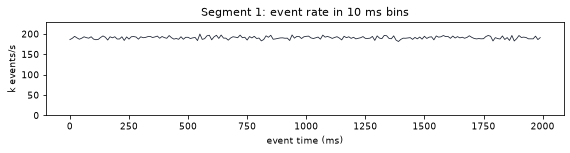

In [4]:
seg1 = streams[0]
t = seg1["t"].astype(np.int64)
print("sorted:", bool(np.all(np.diff(t) >= 0)), "| duration:", (t[-1] - t[0]) / 1e6, "s")
rate = np.bincount(t // 10_000) / 0.010
print(f"events/s in 10 ms bins: min {rate.min():,.0f}, median {np.median(rate):,.0f}, max {rate.max():,.0f}")

fig, ax = plt.subplots(figsize=(8, 2.2))
ax.plot(np.arange(len(rate)) * 10, rate / 1e3, color=INK, lw=0.8)
ax.set(xlabel="event time (ms)", ylabel="k events/s", title="Segment 1: event rate in 10 ms bins")
ax.set_ylim(0, rate.max() / 1e3 * 1.15)
fig.tight_layout()
plt.show()

### Where the events land: finding hot pixels

Counting every event of segment 1 per pixel shows the disc's orbit as a ring, a thin uniform
background, and a few pixels far above everything else. Hot pixels like these exist on real
sensors too, and any centroid or density estimate downstream should mask them. The rule here
is simple: a pixel with more than 20 times the median count of active pixels is hot.

In [5]:
counts = frames2py.Accumulator((W, H), "event_count")
counts.accumulate(seg1)
frame = counts.read()  # (H, W) uint32: Accumulator.read() returns a new array
active = frame[frame > 0]
threshold = 20 * np.median(active)
hot_mask = frame > threshold
print(f"median count of active pixels {np.median(active):.0f}; hot threshold {threshold:.0f}")
found = [(int(x), int(y)) for y, x in np.argwhere(hot_mask)]
print("hot pixels (x, y):", found)
assert sorted(found) == sorted(HOT_PIXELS)  # the three the generator planted, and nothing else

median count of active pixels 2; hot threshold 40
hot pixels (x, y): [(120, 20), (31, 47), (290, 212)]


### Polarity

Over the whole segment ON and OFF events balance, as they should when every pixel the disc
enters it also leaves. In a short window they separate: the `polarity` kernel counts each
pixel's OFF and ON events in two channels, and a 20 ms window shows ON events ahead of the
disc and OFF events behind it.

ON 190,885, OFF 190,842


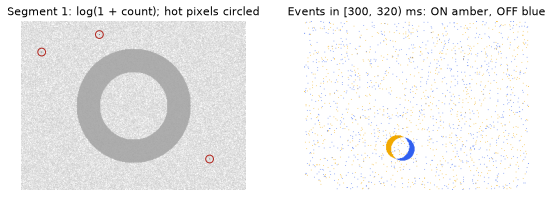

In [6]:
on = int((seg1["p"] != 0).sum())
print(f"ON {on:,}, OFF {len(seg1) - on:,}")

window = seg1[(seg1["t"] >= 300_000) & (seg1["t"] < 320_000)]
pol = frames2py.Accumulator((W, H), "polarity")
pol.accumulate(window)
p_frame = pol.read()  # (H, W, 2): channel 0 OFF, channel 1 ON

fig, (a1, a2) = plt.subplots(1, 2, figsize=(8, 2.8))
a1.imshow(np.log1p(frame), cmap="gray_r")
for x, y in HOT_PIXELS:
    a1.add_patch(plt.Circle((x, y), 6, fill=False, color="#B3261E", lw=1))
a1.set_title("Segment 1: log(1 + count); hot pixels circled")
rgb = np.ones((H, W, 3))
rgb[p_frame[..., 1] > 0] = np.array([242, 169, 0]) / 255   # ON
rgb[p_frame[..., 0] > 0] = np.array([49, 96, 240]) / 255   # OFF
a2.imshow(rgb)
a2.set_title("Events in [300, 320) ms: ON amber, OFF blue")
for a in (a1, a2):
    a.set_axis_off()
fig.tight_layout()
plt.show()

## 4. The live pipeline

*Frames2Py behaviour.* Now the stream is fed live. One producer thread replays the batches
at their recorded pace with `replay.paced()`, 1 ms of events per batch, standing in for the
buffers a camera driver hands over. It calls `ingest()` on two Engines, one per
representation the consumers need:

- `engine_track`: the `polarity` kernel, a windowed kernel (each snapshot holds the events
  since the previous publication), published at the default cadence of at most once per
  16 ms, about a display's frame rate;
- `engine_model`: `StackedHistogram(bins=5, bin_us=10_000)`, the per-polarity time-bin
  histogram some event-vision models take as input: the last five completed 10 ms bins,
  published at most once per 50 ms.

Publication happens inside `ingest()`, on the producer's thread, and each one is a fresh,
read-only frame with its metadata: `sequence`, strictly increasing for the Engine's
lifetime, and `watermark`, the largest accumulated timestamp.

Three consumers run on their own threads. None of them is called by the Engine, and the
producer never waits for any of them:

1. **tracker** blocks in `engine_track.wait_for_newer(last)`, so it wakes when a newer
   snapshot is published instead of polling, and estimates the disc's position;
2. **model** blocks in `engine_model.wait_for_newer(last)`, copies the frame as it would
   before handing it to a model, estimates the disc's velocity, and then sleeps 120 ms to
   stand for inference latency: deliberately slower than the 50 ms cadence;
3. **monitor** polls `snapshot()` and `stats` every 250 ms on its own clock, as a status
   display would.

The tracker's and model's work runs on their threads, not the producer's. `time.sleep()`
releases CPython's interpreter lock; a consumer doing heavy pure-Python work instead would
compete with the producer for that lock on a standard build. Frames2Py adds no waiting of
its own, but it doesn't remove CPython's scheduling.

In [7]:
def centroid(image, minimum=2, at_least=20):
    # Mean position of pixels with at least `minimum` events; None if too few. Requiring two
    # events in a short window removes almost all of the 1 Hz background.
    mask = image >= minimum
    if mask.sum() < at_least:
        return None
    ys, xs = np.nonzero(mask)
    return xs.mean(), ys.mean()


def batches_of(events, batch_us=1_000):
    edges = np.arange(0, int(events["t"][-1]) + batch_us + 1, batch_us)
    cuts = np.searchsorted(events["t"], edges)
    return [events[a:b] for a, b in zip(cuts[:-1], cuts[1:]) if b > a]


BIN_US = 10_000
engine_track = frames2py.Engine((W, H), "polarity")
engine_model = frames2py.Engine((W, H), frames2py.StackedHistogram(bins=5, bin_us=BIN_US), snapshot_interval_ms=50)
done = threading.Event()
errors = []  # an exception in any thread is re-raised below, after the threads finish
log = {"tracker": [], "model": [], "monitor": [], "lag_s": [], "segment_ends": []}


def producer():
    started = time.monotonic()
    try:
        for segment, stream in enumerate(streams):
            if segment:
                # A camera restart: its clock starts again, so the caller calls reset()
                # (Frames2Py never infers a discontinuity from the timestamps).
                log["segment_ends"].append((engine_track.stats, engine_track.snapshot().meta))
                engine_track.reset()
                engine_model.reset()
            start, t0 = time.monotonic(), int(stream["t"][0])
            for batch in replay.paced(batches_of(stream)):
                engine_track.ingest(batch)
                engine_model.ingest(batch)
                log["lag_s"].append(time.monotonic() - start - (int(batch["t"][-1]) - t0) / 1e6)
        engine_track.stop()  # publishes each Engine's pending window
        engine_model.stop()
        log["producer_s"] = time.monotonic() - started
    finally:
        done.set()


def tracker():
    last = None
    while True:
        snapshot = engine_track.wait_for_newer(last, timeout=0.1)
        if snapshot is None:
            if done.is_set():
                return
            continue
        total = snapshot.frame.sum(axis=2, dtype=np.int64)  # OFF + ON per pixel; a new array
        total[hot_mask] = 0
        latest = engine_track.snapshot()
        log["tracker"].append((snapshot.meta.sequence, snapshot.meta.watermark, centroid(total),
                               None if latest is None else latest.meta.watermark))
        last = snapshot.meta.sequence


def model():
    last = None
    while True:
        snapshot = engine_model.wait_for_newer(last, timeout=0.2)
        if snapshot is None:
            if done.is_set():
                return
            continue
        x = snapshot.copy()  # our own writable array: the published frame is shared
        per_bin = x.sum(axis=0, dtype=np.int64)  # (5, H, W): OFF + ON per time bin
        per_bin[:, hot_mask] = 0
        oldest, newest = centroid(per_bin[0]), centroid(per_bin[-1])
        velocity = None
        if oldest is not None and newest is not None:  # bin centres are 4 bins apart
            velocity = ((newest[0] - oldest[0]) / (4 * BIN_US / 1e6), (newest[1] - oldest[1]) / (4 * BIN_US / 1e6))
        time.sleep(0.120)  # stands for model inference
        latest = engine_model.snapshot()
        log["model"].append((snapshot.meta.sequence, snapshot.meta.watermark, velocity,
                             None if latest is None else latest.meta.watermark))
        last = snapshot.meta.sequence


def monitor():
    while not done.is_set():
        snapshot = engine_track.snapshot()
        log["monitor"].append((engine_track.stats, None if snapshot is None else snapshot.meta.sequence))
        time.sleep(0.25)


def guarded(work):
    def run():
        try:
            work()
        except BaseException as error:
            errors.append(error)
            done.set()
    return run


threads = [threading.Thread(target=guarded(f), name=f.__name__) for f in (tracker, model, monitor, producer)]
wall = time.monotonic()
for thread in threads:
    thread.start()
for thread in threads:
    thread.join()
if errors:
    raise errors[0]
print(f"producer: {sum(d for d, _, _ in SEGMENTS) / 1e6:.1f} s of events ingested in {log['producer_s']:.2f} s;",
      f"all threads done after {time.monotonic() - wall:.2f} s (the consumers finish their last work and time out)")

producer: 3.0 s of events ingested in 3.00 s; all threads done after 3.46 s (the consumers finish their last work and time out)


### What each party saw

*Frames2Py behaviour.* The counters and the snapshot metadata tell the story without
instrumenting anything:

- every event of every accepted call is either accumulated or counted as out of bounds;
- the tracker, waiting rather than polling, is woken by each publication and handles it, as
  long as its own work is shorter than the cadence;
- the model, slower than its cadence, handles only some publications. The ones it misses
  are skipped, not queued: the Engine keeps only the latest snapshot;
- the producer kept the recording's pace. `paced()` never skips a batch, so a producer that
  fell behind would show it here as lag.

In [8]:
before_stats, before_meta = log["segment_ends"][0]
print("segment 1, just before reset():", before_stats)
print("after the run:                  ", engine_track.stats)
print("events of segment 1 / 2:", f"{len(streams[0]):,} / {len(streams[1]):,}")
# Every event of an accepted call is accumulated or counted as out of bounds:
assert before_stats.events_ingested == len(streams[0]) and before_stats.events_out_of_bounds == 0
assert engine_track.stats.events_ingested == len(streams[1])

published = engine_track.snapshot().meta.sequence
tracker_seqs = [s for s, *_ in log["tracker"]]
model_seqs = [s for s, *_ in log["model"]]
print(f"\ntracker handled {len(tracker_seqs)} of {published} publications of engine_track")
print(f"model handled {len(model_seqs)} of {engine_model.snapshot().meta.sequence} publications of engine_model;",
      "sequences", model_seqs[:8], "...")
assert all(b > a for a, b in zip(tracker_seqs, tracker_seqs[1:]))  # strictly increasing
print(f"monitor polled {len(log['monitor'])} times; first sequences it saw:",
      [s for _, s in log["monitor"][:6]])

lag_ms = np.array(log["lag_s"]) * 1e3
print(f"\nproducer behind the recording's pace: median {np.median(lag_ms):.1f} ms, max {lag_ms.max():.1f} ms",
      "(this run, on this machine; not a benchmark)")

segment 1, just before reset(): EngineStats(events_ingested=381727, events_out_of_bounds=0, snapshots_published=121, uptime_ns=2001846708)
after the run:                   EngineStats(events_ingested=190985, events_out_of_bounds=0, snapshots_published=62, uptime_ns=3473522292)
events of segment 1 / 2: 381,727 / 190,985

tracker handled 183 of 183 publications of engine_track
model handled 25 of 61 publications of engine_model; sequences [1, 3, 5, 8, 11, 13, 16, 18] ...
monitor polled 12 times; first sequences it saw: [None, 16, 31, 47, 63, 78]

producer behind the recording's pace: median 1.0 ms, max 2.8 ms (this run, on this machine; not a benchmark)


## 5. A lifecycle boundary: `reset()`

*Frames2Py behaviour.* Between the segments the producer called `reset()` on both Engines,
as a program must when its event clock jumps (a camera restart, a new recording). The output
above shows what that does:

- the counters start again: `events_ingested` after the run covers segment 2 only;
- the watermark starts again, from segment 2's first events;
- `sequence` does not: the first publication after the reset is numbered after the last one
  before it. A consumer holding `last` keeps waiting with it and simply receives the next
  publication.

A consumer can see the boundary in the metadata, as the watermark going backwards between
two snapshots it handled. The analysis below uses exactly that to tell the segments apart.

In [9]:
for sequence, watermark, *_ in log["tracker"]:
    if sequence in (before_meta.sequence, before_meta.sequence + 1):
        print(f"tracker: sequence {sequence}, watermark {watermark} µs")
# The first snapshot whose watermark went back is the first after reset(); its sequence
# carried on past every one before the reset.
drop = next(i for i in range(1, len(log["tracker"])) if log["tracker"][i][1] < log["tracker"][i - 1][1])
assert log["tracker"][drop][0] > before_meta.sequence

tracker: sequence 121, watermark 1990999 µs
tracker: sequence 122, watermark 978 µs


## 6. The downstream results

*Downstream analysis on demonstration data.* Two modest results, each checked against the
generator's known trajectory. They show what the consumers computed from the snapshots; they
are not evidence about any real camera, scene or model.

**Position, from the tracker.** A windowed snapshot holds the events since the previous
publication. When the tracker handled the previous publication too (consecutive sequence
numbers) and the watermark didn't go back, the window ran from the previous watermark to
this one, so the centroid is compared with the true centre at the window's midpoint.

**Velocity, from the model.** A `StackedHistogram` frame read at watermark `T` holds the
five completed bins before `T // bin_us`, so the bin centres, and the true velocity at the
middle of the window, follow from the watermark alone. The estimate is the displacement
between the oldest and newest bins' centroids.

**Freshness.** When a consumer finished with a snapshot, how much newer was the latest
published state, in event time? That is the price of being slow, and it is paid by the slow
consumer alone.

In [10]:
def segments_of(entries):
    # The segment index of each entry: the watermark going backwards marks reset().
    segment, previous, out = 0, None, []
    for entry in entries:
        if previous is not None and entry[1] < previous:
            segment += 1
        out.append(segment)
        previous = entry[1]
    return out


track_rows = []  # (segment, window midpoint µs, centroid, error px)
previous = None
for (sequence, watermark, c, _), segment in zip(log["tracker"], segments_of(log["tracker"])):
    if previous and sequence == previous[0] + 1 and watermark >= previous[1] and c is not None:
        mid = (previous[1] + watermark) / 2
        gx, gy = disc_centre(mid, SEGMENTS[segment][1])
        track_rows.append((segment, mid, c, float(np.hypot(c[0] - gx, c[1] - gy))))
    previous = (sequence, watermark)
errors = np.array([r[3] for r in track_rows])
print(f"tracker: {len(errors)} windows compared; position error median {np.median(errors):.1f} px, "
      f"95th percentile {np.percentile(errors, 95):.1f} px, max {errors.max():.1f} px")

speed_err, angle_err = [], []
for (sequence, watermark, v, _), segment in zip(log["model"], segments_of(log["model"])):
    if v is None:
        continue
    k_T = watermark // BIN_US
    t_mid = (k_T - 2.5) * BIN_US  # middle of bins k_T - 5 ... k_T - 1
    tv = disc_velocity(t_mid, SEGMENTS[segment][1])
    speed_err.append(np.hypot(*v) / np.hypot(*tv) - 1)
    angle_err.append(np.degrees(np.angle(complex(*v) / complex(*tv))))
print(f"model: {len(speed_err)} estimates; speed error median {np.median(np.abs(speed_err)) * 100:.0f}%, "
      f"direction error median {np.median(np.abs(angle_err)):.1f} degrees, max {np.max(np.abs(angle_err)):.1f}")


def staleness_ms(entries):
    segs = segments_of(entries)
    return np.array([(latest - w) / 1e3 for (_, w, _, latest), s in zip(entries, segs)
                     if latest is not None and latest >= w])


for name in ("tracker", "model"):
    s = staleness_ms(log[name])
    print(f"{name}: latest state was {np.median(s):.0f} ms (median), {s.max():.0f} ms (max) of event time "
          "newer than the one it had just handled")

tracker: 181 windows compared; position error median 1.8 px, 95th percentile 3.4 px, max 4.1 px
model: 24 estimates; speed error median 4%, direction error median 2.3 degrees, max 8.5
tracker: latest state was 0 ms (median), 0 ms (max) of event time newer than the one it had just handled
model: latest state was 126 ms (median), 153 ms (max) of event time newer than the one it had just handled


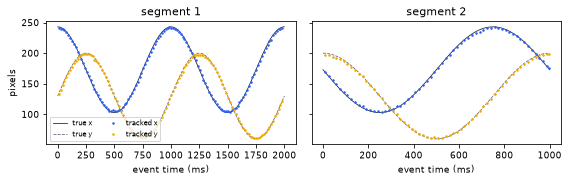

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(8, 2.6), sharey=True)
for segment, ax in enumerate(axes):
    duration, phase, _ = SEGMENTS[segment]
    tt = np.linspace(0, duration, 400)
    gx, gy = disc_centre(tt, phase)
    ax.plot(tt / 1e3, gx, color=INK, lw=0.8, label="true x")
    ax.plot(tt / 1e3, gy, color="#5B6478", lw=0.8, ls="--", label="true y")
    rows = [r for r in track_rows if r[0] == segment]
    ax.plot([r[1] / 1e3 for r in rows], [r[2][0] for r in rows], ".", ms=3, color=BLUE, label="tracked x")
    ax.plot([r[1] / 1e3 for r in rows], [r[2][1] for r in rows], ".", ms=3, color=AMBER, label="tracked y")
    ax.set(title=f"segment {segment + 1}", xlabel="event time (ms)")
axes[0].set_ylabel("pixels")
axes[0].legend(loc="lower left", fontsize=7, ncol=2)
fig.tight_layout()
plt.show()

Reading the results:

- The tracker's centroid follows the disc to within a few pixels in this synthetic scene.
  It is a sanity check of the pipeline, not an evaluation of a tracking method.
- The model's velocity from the oldest and newest bins is close to the true velocity. Again,
  this checks that the temporal frame and its watermark carry the timing the consumer needs.
- The slow model's results describe a state about 100 to 150 ms older than the newest one
  published by the time each result is ready. That staleness is the consumer's own: the
  tracker, on the same producer, stayed current, and the producer kept the recording's
  pace.

## 7. What you would replace

- **The event source.** Instead of `generate()`, convert your camera SDK's buffers to
  `EVENT_DTYPE` in its callback or read loop, or use a file adapter
  (`frames2py.adapters.evt`, `aedat4`, `hdf5`) with `replay.paced()` to replay a recording
  at its own pace. On a camera restart or a new recording, call `reset()`.
- **The representations.** Choose kernels for what your consumers need: windowed counts,
  a time surface, decays, or the temporal kernels for models; see the kernels page of the
  documentation.
- **The consumer work.** The tracker's centroid and the model's sleep stand for your own
  processing: a model (copy the snapshot first, as here; the PyTorch recipe in the docs
  shows the hand-off), a display (`frames2py.viewer`), a logger. Keep it on its own thread,
  wait with `wait_for_newer()` when you want every state you can keep up with, or poll on
  your own clock when you run at a fixed rate.
- **The analysis.** Ground truth exists here only because the data is synthetic. With real
  data you would compare against your own labels or a reference system.

What stays the same is the shape: one producer calling `ingest()`, publications at a cadence
you choose, and consumers that each take the latest state at their own pace.